# Task 2 — Data Preprocessing for a Regression Problem

## Uber Fare Prediction

This project focuses on preparing an Uber fare dataset for a regression problem.

The objective is to build a complete machine learning preprocessing and modeling pipeline that includes:

- Missing value analysis and imputation
- Duplicate detection
- Categorical encoding
- Feature scaling
- Feature engineering
- Feature selection
- Outlier analysis
- Train/Test split
- Cross-validation
- Baseline regression model
- Hyperparameter tuning
- Final model evaluation
- Reusable Scikit-learn Pipeline
- Saving the final pipeline with Joblib

The target variable is `fare_amount`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.feature_selection import SelectPercentile, f_regression

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import randint

## 1. Load the Dataset

The cleaned Uber dataset from Task 1 is loaded for the preprocessing stage.

The target variable is `fare_amount`, which is a continuous numerical variable suitable for regression.

In [2]:
df = pd.read_csv("uber_cleaned.csv")

print(f"Dataset shape: {df.shape}")

Dataset shape: (487742, 26)


## 2. Define the Target and Features

The target variable is `fare_amount`.

The selected features describe:

- Car condition
- Weather
- Traffic condition
- Pickup and dropoff locations
- Passenger count
- Time information
- Airport distances
- NYC distance
- Trip distance
- Trip bearing

These variables were selected because they can provide information about the fare amount.

In [3]:
features = [
    "Car Condition",
    "Weather",
    "Traffic Condition",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "hour",
    "day",
    "month",
    "weekday",
    "year",
    "jfk_dist",
    "ewr_dist",
    "lga_dist",
    "sol_dist",
    "nyc_dist",
    "distance",
    "bearing"
]

target = "fare_amount"

X = df[features].copy()
y = df[target].copy()

## 3. Missing Value Analysis

Missing values are quantified using both the number and percentage of missing observations.

The preprocessing strategy will be handled inside the machine learning Pipeline so that imputers are fitted only on training data during cross-validation.

In [4]:
missing_summary = pd.DataFrame({
    "Missing Count": X.isnull().sum(),
    "Missing Percentage": X.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

if missing_summary.empty:
    print("No missing values were found in the selected features.")
else:
    display(missing_summary)

No missing values were found in the selected features.


## Missing Value Decision

Numeric features will use median imputation because median imputation is robust to skewed distributions and outliers, which are common in fare and trip-related data.

Categorical features will use the most frequent category.

The imputers are placed inside the Pipeline to prevent data leakage.

In [5]:
numeric_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "hour",
    "day",
    "month",
    "weekday",
    "year",
    "jfk_dist",
    "ewr_dist",
    "lga_dist",
    "sol_dist",
    "nyc_dist",
    "distance",
    "bearing"
]

categorical_features = [
    "Weather",
    "Traffic Condition"
]

ordinal_features = [
    "Car Condition"
]

## 4. Duplicate Detection

Exact duplicates are checked across all columns.

Exact duplicate rows are considered redundant because they represent identical observations.

Only exact duplicates are removed. Similar-looking rows are not automatically removed because they may represent valid Uber trips.

In [6]:
duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count}")

df = df.drop_duplicates().copy()

print(f"Dataset shape after duplicate removal: {df.shape}")

Exact duplicate rows: 0
Dataset shape after duplicate removal: (487742, 26)


## 5. Rebuild Features After Duplicate Removal

After removing exact duplicates, the feature matrix and target variable are recreated to ensure that the modeling data matches the cleaned dataset.

In [7]:
X = df[features].copy()
y = df[target].copy()

## 6. Feature Engineering

The dataset already contains useful engineered features from Task 1.

Examples include:

- `distance` — total trip distance
- `bearing` — direction of the trip
- `jfk_dist`, `ewr_dist`, `lga_dist` — distances to major airports
- `nyc_dist` — distance related to the NYC location
- `hour`, `day`, `month`, `weekday`, `year` — decomposed time features

These features are retained because they provide more useful information for regression than using only the raw trip coordinates.

In [8]:
# Existing engineered features are already available in the dataset.

X = X.copy()

## 7. Train/Test Split

The dataset is split before fitting any preprocessing transformation.

This is important for preventing data leakage.

The test set is kept untouched and will only be used for the final evaluation.

An 80/20 split is used with `random_state=42` for reproducibility.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (390193, 20)
Testing set: (97549, 20)


## 8. Outlier Detection

Regression models can be sensitive to extreme target values because large errors receive more weight in squared-error metrics.

The IQR method is used to identify extreme fare values.

Outliers are not automatically removed because an unusually high Uber fare may represent a real trip rather than a data-entry error.

Therefore, the detected outliers are kept so the model can learn from legitimate high-value trips.

In [10]:
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (y_train < lower_bound) |
    (y_train > upper_bound)
)

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Detected outliers: {outliers.sum()}")
print(f"Outlier percentage: {outliers.mean() * 100:.2f}%")

Lower bound: -3.75
Upper bound: 22.25
Detected outliers: 33702
Outlier percentage: 8.64%


## 9. Preprocessing Strategy

The preprocessing pipeline uses different transformations according to the type of feature.

### Numeric Features
- Median imputation
- StandardScaler

Scaling is useful for Linear Regression because the numeric features have very different ranges.

### Nominal Categorical Features
- Most frequent imputation
- One-Hot Encoding

`Weather` and `Traffic Condition` do not have a natural numerical order.

### Ordinal Feature
- Most frequent imputation
- Ordinal Encoding

`Car Condition` has a meaningful order:

Bad < Good < Very Good < Excellent

In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["Bad", "Good", "Very Good", "Excellent"]]
    ))
])

## 10. ColumnTransformer

A `ColumnTransformer` combines all preprocessing steps into one object.

This ensures that the same preprocessing logic is applied consistently to training and testing data.

It also prevents preprocessing leakage during cross-validation.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        ("ordinal", ordinal_pipeline, ordinal_features)
    ],
    remainder="drop"
)

## 11. Baseline Regression Model

Linear Regression is used as the baseline model.

The complete preprocessing process is placed inside the same Pipeline as the model.

This ensures that preprocessing is fitted separately inside every cross-validation training fold.

In [13]:
baseline_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

## 12. Baseline Cross-Validation

Five-fold cross-validation is used because this is a standard approach for independent tabular regression data.

The model is evaluated using:

- MAE
- RMSE
- R²

The preprocessing pipeline is refitted independently inside every fold.

In [14]:
cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)

baseline_mae_cv = -cv_results["test_MAE"].mean()
baseline_rmse_cv = -cv_results["test_RMSE"].mean()
baseline_r2_cv = cv_results["test_R2"].mean()

print(f"Baseline CV MAE: {baseline_mae_cv:.4f}")
print(f"Baseline CV RMSE: {baseline_rmse_cv:.4f}")
print(f"Baseline CV R²: {baseline_r2_cv:.4f}")

Baseline CV MAE: 2.4369
Baseline CV RMSE: 4.9585
Baseline CV R²: 0.7319


## 13. Fit the Baseline Model

After cross-validation, the baseline pipeline is fitted on the complete training set.

The untouched test set is then used for the first final evaluation.

In [15]:
baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline Test MAE: {baseline_mae:.4f}")
print(f"Baseline Test RMSE: {baseline_rmse:.4f}")
print(f"Baseline Test R²: {baseline_r2:.4f}")

Baseline Test MAE: 2.4143
Baseline Test RMSE: 4.8874
Baseline Test R²: 0.7368


## 14. Hyperparameter-Tuned Random Forest

Random Forest is selected as the tuned model because it can capture nonlinear relationships between trip characteristics and fare amount.

RandomizedSearchCV is used to search through multiple hyperparameter combinations while keeping the computational cost lower than an exhaustive Grid Search.

The tuning process uses five-fold cross-validation and is performed only on the training data.

In [16]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", SelectPercentile(
        score_func=f_regression,
        percentile=80
    )),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

## 15. Hyperparameter Search Space

The main Random Forest parameters being tuned are:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

The search is performed using five-fold cross-validation with negative RMSE as the optimization metric.

In [17]:
param_distributions = {
    "model__n_estimators": randint(50, 151),
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", "log2", 0.7, 1.0]
}

## 16. Randomized Hyperparameter Search

RandomizedSearchCV evaluates randomly selected hyperparameter combinations using five-fold cross-validation.

The final test set is not used during tuning, which keeps it as an unbiased hold-out set for the final evaluation.

In [18]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
4 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
          

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....001EA091D0190>, 'model__min_samples_split': <scipy.stats....001EA19EA7ED0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations ot

## 17. Best Hyperparameters

The best hyperparameter configuration is selected according to the cross-validated RMSE obtained on the training data.

In [19]:
print("Best Parameters:")
print(random_search.best_params_)

print(
    f"\nBest Cross-Validation RMSE: "
    f"{-random_search.best_score_:.4f}"
)

Best Parameters:
{'model__max_depth': 20, 'model__max_features': 0.7, 'model__min_samples_leaf': 5, 'model__min_samples_split': 5, 'model__n_estimators': 73}

Best Cross-Validation RMSE: 3.6028


## 18. Final Tuned Model Evaluation

The best tuned pipeline is evaluated once on the untouched test set.

The final metrics are:

- MAE
- RMSE
- R²

These metrics represent the model's performance on unseen data.

In [20]:
tuned_model = random_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_pred)
)

tuned_r2 = r2_score(y_test, tuned_pred)

print(f"Tuned Model Test MAE: {tuned_mae:.4f}")
print(f"Tuned Model Test RMSE: {tuned_rmse:.4f}")
print(f"Tuned Model Test R²: {tuned_r2:.4f}")

Tuned Model Test MAE: 1.6465
Tuned Model Test RMSE: 3.4732
Tuned Model Test R²: 0.8671


## 19. Baseline vs Tuned Model

The baseline Linear Regression model and the tuned Random Forest model are compared using the same untouched test set.

MAE and RMSE measure prediction error, where lower values are better.

R² measures the proportion of variance explained by the model, where higher values indicate better explanatory performance.

In [21]:
results = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Tuned Random Forest"
    ],
    "MAE": [
        baseline_mae,
        tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],
    "R²": [
        baseline_r2,
        tuned_r2
    ]
})

results

,Model,MAE,RMSE,R²
0,Baseline Linear Regression,2.414296,4.887359,0.736808
1,Tuned Random Forest,1.646532,3.473193,0.867083


## 20. Actual vs Predicted Fare

The following visualization compares the actual fare values with the predictions produced by the tuned Random Forest model.

Predictions that are closer to the ideal relationship between actual and predicted values indicate smaller prediction errors.

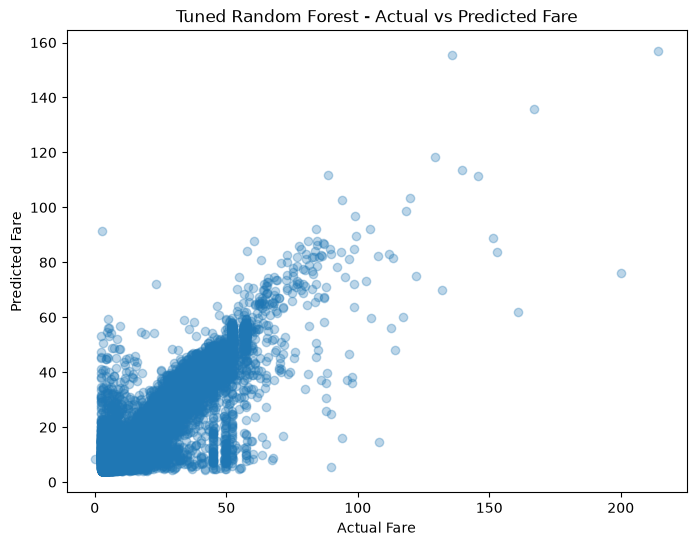

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_pred,
    alpha=0.3
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Tuned Random Forest - Actual vs Predicted Fare")

plt.show()

## 21. Residual Analysis

Residuals are calculated as:

Residual = Actual Fare - Predicted Fare

Residual analysis helps identify systematic prediction errors and large deviations between actual and predicted fares.

In [23]:
residuals = y_test - tuned_pred

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Mean Absolute Residual: {np.abs(residuals).mean():.4f}")
print(f"Minimum Residual: {residuals.min():.4f}")
print(f"Maximum Residual: {residuals.max():.4f}")

Mean Residual: -0.0337
Mean Absolute Residual: 1.6465
Minimum Residual: -88.4556
Maximum Residual: 123.7025


## 22. Residual Plot

The residual plot shows prediction errors against predicted fare values.

A good regression model should generally have residuals distributed around zero without a strong systematic pattern.

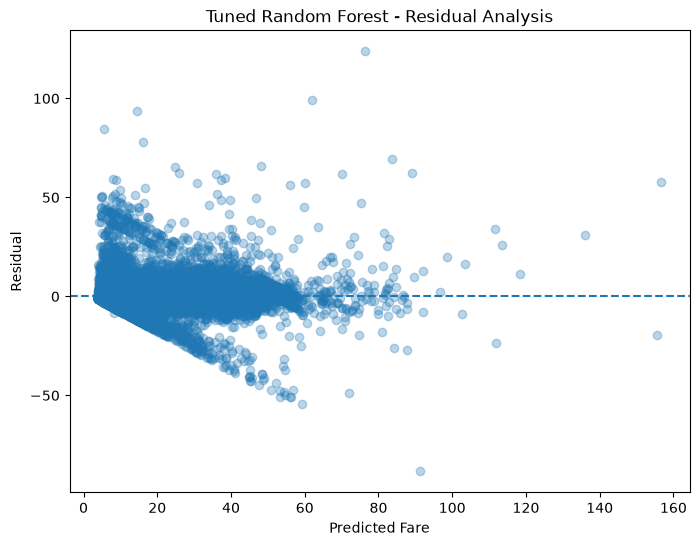

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    tuned_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Tuned Random Forest - Residual Analysis")

plt.show()

## 23. Save the Final Pipeline

The complete tuned pipeline is saved using Joblib.

The saved object contains:

- Missing value handling
- Encoding
- Scaling
- Feature selection
- The trained Random Forest model

This allows the same preprocessing and prediction workflow to be reused later without manually repeating the preprocessing steps.

In [25]:
joblib.dump(
    tuned_model,
    "uber_fare_prediction_pipeline.joblib"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


## 24. Test the Saved Pipeline

The saved pipeline is loaded again to verify that it can be used for prediction as a reusable machine learning object.

In [26]:
loaded_pipeline = joblib.load(
    "uber_fare_prediction_pipeline.joblib"
)

loaded_predictions = loaded_pipeline.predict(
    X_test.head(5)
)

loaded_predictions

array([ 5.64357548, 17.84848663,  5.07326026,  4.81413996, 13.20785002])

## 25. Final Conclusion

The preprocessing workflow was designed to avoid data leakage by fitting preprocessing transformations only on training data through Scikit-learn Pipelines.

The baseline Linear Regression model provides a reference point for performance.

The Random Forest model uses nonlinear modeling and feature selection and is tuned using cross-validation.

The final model is evaluated on a completely untouched test set using MAE, RMSE, and R².

The complete preprocessing and modeling workflow has also been saved as a reusable Joblib Pipeline.

In [27]:
print("Final Model Performance")
print("-" * 30)

print(f"MAE : {tuned_mae:.4f}")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"R²  : {tuned_r2:.4f}")

print("\nSaved Pipeline:")
print("uber_fare_prediction_pipeline.joblib")

Final Model Performance
------------------------------
MAE : 1.6465
RMSE: 3.4732
R²  : 0.8671

Saved Pipeline:
uber_fare_prediction_pipeline.joblib


## 26. What I Would Try Next

Possible next steps include:

- Testing Gradient Boosting or HistGradientBoosting.
- Experimenting with different feature-selection thresholds.
- Engineering cyclical features for `hour` and `weekday`.
- Testing target transformations if the fare distribution is strongly skewed.
- Exploring additional interaction features between distance, traffic, and time.
- Comparing the tuned Random Forest with other tree-based regression algorithms.